# 2026-03-08 TODO

|TODO|내용|비고|구현 일시|
|:---:|:---:|:---:|:---:|
|[ ]|1. GCP BigQuery에서 Polars으로 상담 데이터 클러스터링||2026/03/08-2026/03/14|

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from google.cloud import bigquery
from google.oauth2 import service_account

key_path = '/workspaces/Psychological-counseling-researching/.key/testprojects-453622-d1f78fcce8b7.json'
credentials = service_account.Credentials.from_service_account_file(key_path)

client = bigquery.Client(credentials=credentials, project=credentials.project_id)
print(f"Client created with project: {client.project}")

Client created with project: testprojects-453622


## 1. GCP BigQuery에서 Polars으로 상담 데이터 클러스터링

UMAP를 기반으로 텍스트 클러스터링 진행.

### 용어 설명

* UMAP (Uniform Manifold Approximation and Projection)

In [13]:
# 1. BigQuery에서 데이터 가져오기 (이전 셀에서 생성된 client 활용)
# 테스트를 위해 우선 5000건의 샘플 데이터를 추출합니다.
query = """
    SELECT split_contents 
    FROM `testprojects-453622.Psychological_counseling_data.morpheme_classification` 
    WHERE 
		split_contents IS NOT NULL AND
		-- file_code="A094" AND
		-- Speaker="내담자" AND
		session_no=1
"""
df = client.query(query).to_dataframe()
counseling_data = df['split_contents'].dropna().tolist()
print(f"가져온 데이터 수: {len(counseling_data)}")

가져온 데이터 수: 23745


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. 텍스트 벡터화 (의미가 아닌 '표현 형태' 집중)
print("2. 표현 형태(말투/구조) 기반 벡터화를 진행 중입니다...")
# analyzer='char_wb'는 단어 경계 안에서 글자 패턴을 추출하여 어미, 뉘앙스 파악에 유리합니다.
# 데이터 수가 많아질 경우 메모리 부족을 방지하기 위해 max_features 제한
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=10000)
embeddings = vectorizer.fit_transform(counseling_data).toarray()

2. 표현 형태(말투/구조) 기반 벡터화를 진행 중입니다...


In [15]:
import umap

# 3. UMAP을 이용한 차원 축소
print("3. UMAP으로 차원 축소를 진행 중입니다...")
umap_model = umap.UMAP(n_neighbors=15, 
                       n_components=2, 
                       metric='cosine', 
                       random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

3. UMAP으로 차원 축소를 진행 중입니다...


/usr/local/python/3.12.1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


In [16]:
import hdbscan

# 4. HDBSCAN을 이용한 밀도 기반 클러스터링
print("4. HDBSCAN으로 클러스터링을 진행 중입니다...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, 
                            metric='euclidean', 
                            cluster_selection_method='eom')
clusters = clusterer.fit_predict(umap_embeddings)

4. HDBSCAN으로 클러스터링을 진행 중입니다...



--- 클러스터링 결과 샘플 ---
                                     split_contents  Cluster_ID
0                                         선생님반갑습니다.          16
1  저희이제선생님하고8회기동안상담을진행하게될거이고요.저는@COUNSELOR이라고합니다.          73
2                                            반갑습니다.          36
3                                     @NAME선생님맞으시죠?         357
4                             저가혹시호칭은선생님이라고부르면될까요?         334
5                                 아니면원하시는호칭이있으실까요?         340
6                                 편한대로부르면.뭐가편할까요?         265
7                         학교에서선생님이라는호칭그래도익숙하시지않으세요?          -1
8                                            어떻으세요?          93
9                                        요즘은그런것같어요.          94
5. 시각화 생성 중...


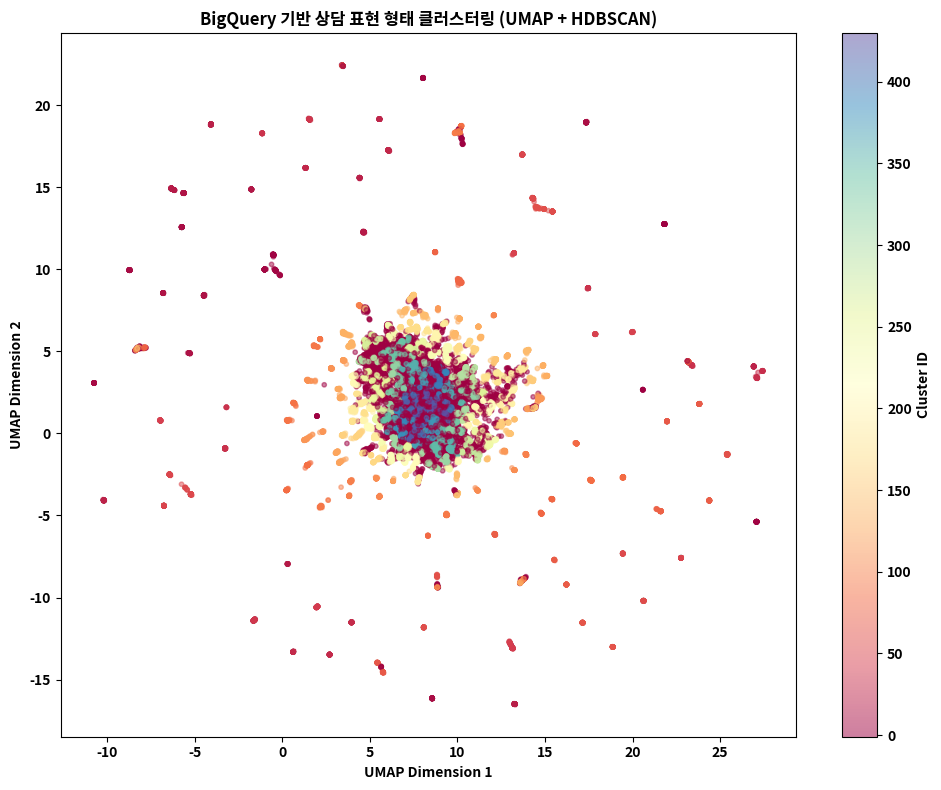

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 5. 결과 데이터프레임 매핑
df['Cluster_ID'] = clusters
print("\n--- 클러스터링 결과 샘플 ---")
print(df.head(10))

# 6. 시각화 (산점도)
print("5. 시각화 생성 중...")

font_path = '/workspaces/Psychological-counseling-researching/.fonts/NotoSansKR-Bold.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 8))
# 노이즈(-1)는 회색, 나머지는 컬러로 표시
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], 
                      c=clusters, cmap='Spectral', s=10, alpha=0.5)
plt.title('BigQuery 기반 상담 표현 형태 클러스터링 (UMAP + HDBSCAN)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()
